# 03 · 탐색적 데이터 분석 (EDA)

> Part 3 · *02의 이론이 실제 데이터에서 성립하는지 눈으로 확인한다.*

정제된 데이터(`data/clean/lotto_clean.db`)로 로또 6/45의 구조를 탐색합니다.
핵심 질문: **관측된 분포가 "완전 무작위(uniform)" 모델과 얼마나 일치하는가?**
여기서는 눈으로 확인하고(EDA), 다음 노트북(03)에서 통계 검정으로 판정합니다.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.lotto_ds import viz, features
from src.lotto_ds.cleaning import load_clean

viz.apply_style()

draws = load_clean("draws")
feat = features.draw_features(draws)
n_draws = len(draws)
print(f"분석 대상: 로또 {n_draws:,}회 (draw {draws.draw_no.min()}–{draws.draw_no.max()})")

분석 대상: 로또 1,230회 (draw 1–1230)


## 1. 번호별 출현 빈도 (Number frequency)

45개 번호가 균등하다면, 각 번호의 기대 출현 횟수는 `n_draws × 6 / 45`입니다.
막대는 관측값, 점선은 균등 기대값.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


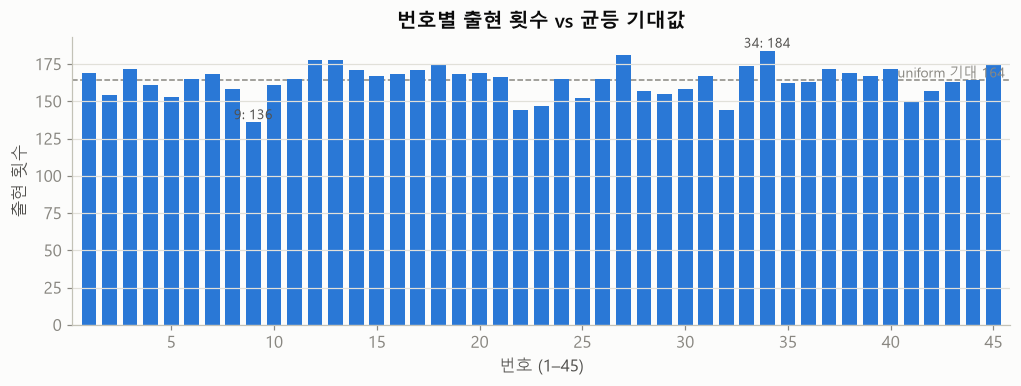

최다 184회 · 최소 136회 · 격차 48회 (기대 164)
→ 격차가 커 보이지만, 이게 '무작위 잡음' 범위인지는 03에서 카이제곱으로 검정합니다.


In [2]:
freq = features.number_frequency(draws)
expected = freq["expected_count"].iloc[0]

fig, ax = plt.subplots(figsize=(11, 3.4))
bars = ax.bar(freq["number"], freq["count"], color=viz.CAT[0], width=0.72)
# 최다·최소 출현 번호만 직접 라벨 (selective direct labels)
for idx in [freq["count"].idxmax(), freq["count"].idxmin()]:
    r = freq.loc[idx]
    ax.annotate(f"{int(r.number)}: {int(r['count'])}", (r.number, r["count"]),
                ha="center", va="bottom", fontsize=9, color=viz.INK["secondary"])
viz.reference_line(ax, expected, label=f"uniform 기대 {expected:.0f}")
ax.set_title("번호별 출현 횟수 vs 균등 기대값")
ax.set_xlabel("번호 (1–45)"); ax.set_ylabel("출현 횟수")
ax.set_xticks(range(0, 46, 5)); ax.margins(x=0.01)
viz.savefig(fig, "02_number_frequency.png"); plt.show()

spread = freq["count"].max() - freq["count"].min()
print(f"최다 {freq['count'].max()}회 · 최소 {freq['count'].min()}회 · 격차 {spread}회 (기대 {expected:.0f})")
print("→ 격차가 커 보이지만, 이게 '무작위 잡음' 범위인지는 03에서 카이제곱으로 검정합니다.")

## 2. 당첨번호 합계 분포 (Sum distribution)

6개 번호 합계는 이론상 21~255, 대칭성에 의해 **정확한 평균은 138**입니다.
관측 분포에 정규근사(CLT)를 겹쳐 봅니다.

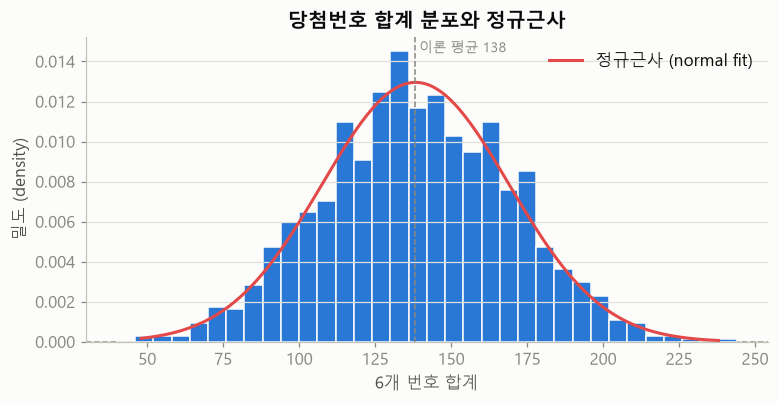

관측 평균 138.29 (이론 138) · 표준편차 30.79
왜도(skew) 0.014 · 첨도(kurtosis) -0.244 — 종 모양에 매우 가까움


In [3]:
ref = features.sum_distribution_reference()
s = feat["sum"]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(s, bins=range(40, 245, 6), color=viz.CAT[0], edgecolor=viz.INK["surface"], linewidth=1.0, density=True)
xs = np.linspace(s.min(), s.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, s.mean(), s.std()), color=viz.CAT[5], lw=2, label="정규근사 (normal fit)")
viz.reference_line(ax, 0, label="")  # keep baseline
ax.axvline(ref["mean"], ls="--", lw=1.0, color=viz.INK["muted"])
ax.text(ref["mean"], ax.get_ylim()[1]*0.95, f" 이론 평균 {ref['mean']:.0f}", fontsize=9, color=viz.INK["muted"])
ax.set_title("당첨번호 합계 분포와 정규근사")
ax.set_xlabel("6개 번호 합계"); ax.set_ylabel("밀도 (density)")
ax.legend(frameon=False, loc="upper right")
viz.savefig(fig, "02_sum_distribution.png"); plt.show()

print(f"관측 평균 {s.mean():.2f} (이론 138) · 표준편차 {s.std():.2f}")
sk, ku = stats.skew(s), stats.kurtosis(s)
print(f"왜도(skew) {sk:.3f} · 첨도(kurtosis) {ku:.3f} — 종 모양에 매우 가까움")

관측 평균이 이론값 138에 거의 정확히 일치합니다 — 조작되지 않은 균등 추첨의 강력한 증거.

## 3. 홀짝 · 고저 균형 (Odd/Even & High/Low balance)

6개 중 홀수 개수, 그리고 고번호(23–45) 개수의 분포. 균등 모델의 기대(이항 근사)와 비교.

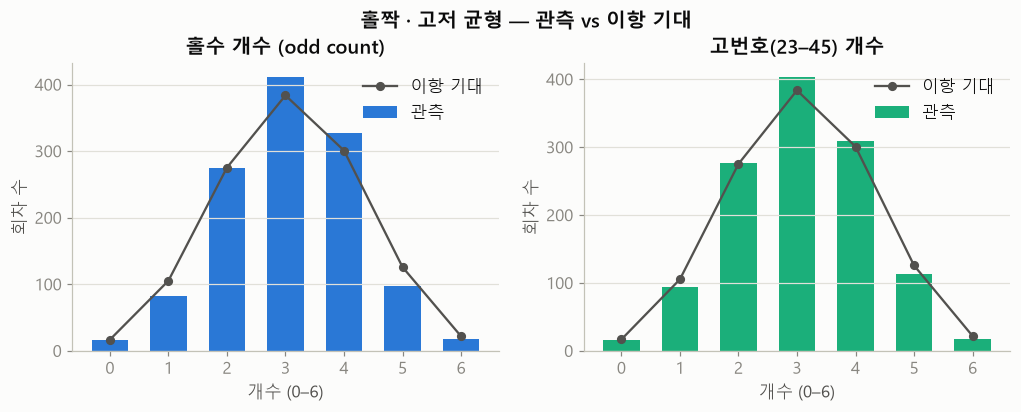

→ 관측(막대)이 이항 기대(선)를 촘촘히 따라감. 특정 균형이 '유리'하다는 신호 없음.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col, title, hue in [
    (axes[0], "odd_count", "홀수 개수 (odd count)", viz.CAT[0]),
    (axes[1], "high_count", "고번호(23–45) 개수", viz.CAT[1]),
]:
    obs = feat[col].value_counts().reindex(range(7), fill_value=0).sort_index()
    # 균등 근사 기대: 홀수 23/45, 고번호 23/45 -> Binomial(6, 23/45)
    p = 23 / 45
    exp = stats.binom.pmf(range(7), 6, p) * n_draws
    ax.bar(obs.index, obs.values, color=hue, width=0.62, label="관측")
    ax.plot(range(7), exp, "o-", color=viz.INK["secondary"], ms=5, lw=1.5, label="이항 기대")
    ax.set_title(title); ax.set_xlabel("개수 (0–6)"); ax.set_ylabel("회차 수")
    ax.legend(frameon=False)
fig.suptitle("홀짝 · 고저 균형 — 관측 vs 이항 기대", y=1.02, fontsize=13, fontweight="600")
viz.savefig(fig, "02_odd_high_balance.png"); plt.show()
print("→ 관측(막대)이 이항 기대(선)를 촘촘히 따라감. 특정 균형이 '유리'하다는 신호 없음.")

## 4. 합계의 시계열 안정성 (Rolling stability over time)

시간에 따라 평균이 흐르는가? 50회 이동평균으로 확인. 흐른다면 추세(예측 여지)가 있다는 뜻.

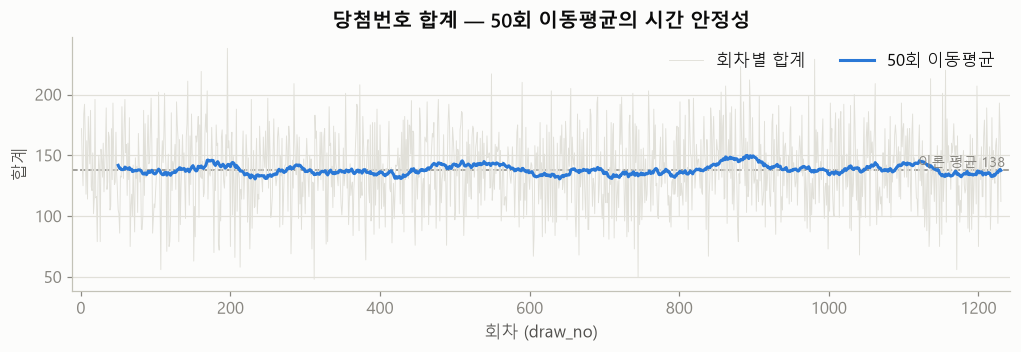

이동평균 범위 130.6–149.9 (이론 138 주변에서 평평)
→ 뚜렷한 추세·주기 없음. 시간축에서 예측할 구조가 보이지 않음.


In [5]:
roll = feat.set_index("draw_no")["sum"].rolling(50).mean()
fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(feat["draw_no"], feat["sum"], color=viz.INK["grid"], lw=0.6, zorder=1, label="회차별 합계")
ax.plot(roll.index, roll.values, color=viz.CAT[0], lw=2, zorder=2, label="50회 이동평균")
viz.reference_line(ax, ref["mean"], label="이론 평균 138")
ax.set_title("당첨번호 합계 — 50회 이동평균의 시간 안정성")
ax.set_xlabel("회차 (draw_no)"); ax.set_ylabel("합계")
ax.legend(frameon=False, loc="upper right", ncol=2); ax.margins(x=0.01)
viz.savefig(fig, "02_rolling_sum.png"); plt.show()
print(f"이동평균 범위 {roll.min():.1f}–{roll.max():.1f} (이론 138 주변에서 평평)")
print("→ 뚜렷한 추세·주기 없음. 시간축에서 예측할 구조가 보이지 않음.")

## 5. AC 값 · 연속번호 · 십분위 커버리지

커뮤니티가 즐겨 쓰는 '패턴' 지표들의 실제 분포.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


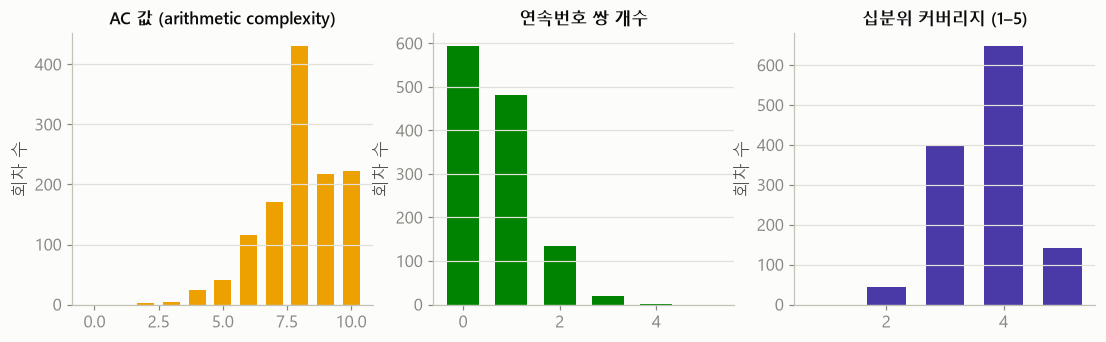

AC 최빈값 8 · 연속쌍 평균 0.66회
→ 이 지표들은 특정 값에 몰려 있지만, 그것은 '조합론적으로 그 값이 더 많기 때문'.
   즉 당첨 확률과는 무관 — 09 백테스트에서 확인.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, col, title, hue, rng in [
    (axes[0], "ac_value", "AC 값 (arithmetic complexity)", viz.CAT[2], range(0, 11)),
    (axes[1], "consecutive_pairs", "연속번호 쌍 개수", viz.CAT[3], range(0, 6)),
    (axes[2], "decades_covered", "십분위 커버리지 (1–5)", viz.CAT[4], range(1, 6)),
]:
    obs = feat[col].value_counts().reindex(rng, fill_value=0).sort_index()
    ax.bar(obs.index, obs.values, color=hue, width=0.66)
    ax.set_title(title, fontsize=11); ax.set_ylabel("회차 수")
viz.savefig(fig, "02_pattern_features.png"); plt.show()
print(f"AC 최빈값 {feat['ac_value'].mode().iloc[0]} · 연속쌍 평균 {feat['consecutive_pairs'].mean():.2f}회")
print("→ 이 지표들은 특정 값에 몰려 있지만, 그것은 '조합론적으로 그 값이 더 많기 때문'.")
print("   즉 당첨 확률과는 무관 — 09 백테스트에서 확인.")

## 6. 연금복권 — 자릿수 위치별 균등성 (Pension digit uniformity)

02번에서 다룬 대비의 **경험적 확인**입니다. 연금복권은 로또와 달리 각 자리가 *독립·복원*이라
정확히 Uniform{0–9}여야 합니다. 6개 위치 × 10개 자릿수 히트맵으로 확인합니다.

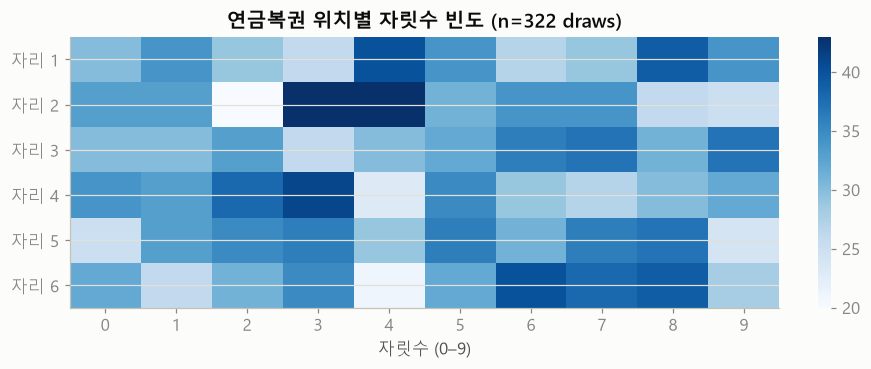

자리당 각 숫자 기대 빈도 32.2 — 히트맵이 대체로 균일. 04에서 위치별 카이제곱으로 검정.


In [7]:
pension = load_clean("pension_draws")
digit_cols = [f"n{i}" for i in range(1, 7)]
pos_freq = np.zeros((6, 10))
for pi, col in enumerate(digit_cols):
    vc = pd.to_numeric(pension[col], errors="coerce").value_counts()
    for d in range(10):
        pos_freq[pi, d] = vc.get(d, 0)

fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(pos_freq, aspect="auto", cmap="Blues")
ax.set_yticks(range(6), [f"자리 {i}" for i in range(1, 7)])
ax.set_xticks(range(10)); ax.set_xlabel("자릿수 (0–9)")
ax.set_title(f"연금복권 위치별 자릿수 빈도 (n={len(pension)} draws)")
cbar = fig.colorbar(im, ax=ax, fraction=0.025); cbar.outline.set_visible(False)
viz.savefig(fig, "02_pension_digits.png"); plt.show()
exp_p = len(pension) / 10
print(f"자리당 각 숫자 기대 빈도 {exp_p:.1f} — 히트맵이 대체로 균일. 04에서 위치별 카이제곱으로 검정.")

### EDA 요약
- 번호 빈도·합계·홀짝·고저 모두 **균등/이항 기대에 밀착**.
- 합계 평균은 이론값 138과 사실상 일치, 시간축에서 추세 없음.
- '패턴' 지표의 편중은 **조합론적 산물**이지 확률적 우위가 아님.
- 다음(04): 이 관찰들을 **카이제곱·런 검정·자기상관 + 효과크기·검정력**으로 정식 검정.